Question
How do operating conditions affect the sensor measeasurments identified as potential engine degradation indicators?

Objective 
Investigate the relationship between the three engine operating settings and the key sensor measurements identified in previous analyses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
column_names=["engine_id","cycle"]+[f"setting_{i}" for i in range(1,4)]+[f"sensor_{i}" for i in range(1,22)]

df=pd.read_csv('../data/raw/train_FD001.txt',sep=r'\s+',header=None)

df.columns=column_names

df["max_cycle"]=df.groupby("engine_id")["cycle"].transform("max")
df["life_percent"]= (df["cycle"]/df["max_cycle"])*100

key_sensors=['sensor_4','sensor_7','sensor_11','sensor_12','sensor_15']

In [3]:
df[['setting_1','setting_2','setting_3']].describe()

,setting_1,setting_2,setting_3
count,20631.000000,20631.000000,20631.0
mean,-0.000009,0.000002,100.0
std,0.002187,0.000293,0.0
min,-0.008700,-0.000600,100.0
25%,-0.001500,-0.000200,100.0
50%,0.000000,0.000000,100.0
75%,0.001500,0.000300,100.0
max,0.008700,0.000600,100.0


Setting 1 and Setting 2 occur through a range of values of -0.0087 to 0.0087 and -0.0006 to 0.0006 respectively, having a standard deviation greater than 0 showing they vary. Setting 3 has a standard deviation value of 0 ,and has the same minimum value and maximum value of 100. This indicates that seeting 3 values are constant. 

In [4]:
print("Setting 1:", df["setting_1"].nunique())
print("Setting 2:", df["setting_2"].nunique())
print("Setting 3:", df["setting_3"].nunique())

Setting 1: 158
Setting 2: 13
Setting 3: 1


In [5]:
print("Setting 1:", df["setting_1"].unique())
print("Setting 2:", df["setting_2"].unique())
print("Setting 3:", df["setting_3"].unique())

Setting 1: [-0.0007  0.0019 -0.0043  0.0007 -0.0019  0.001  -0.0034  0.0008 -0.0033
  0.0018  0.0016  0.0009 -0.0018  0.0006  0.0002 -0.0031  0.0032 -0.0037
 -0.0012  0.0034 -0.001   0.0023  0.     -0.0024  0.0012 -0.0022  0.0014
  0.0005 -0.0042  0.0015  0.0003 -0.0004 -0.003   0.0033 -0.0027 -0.0001
 -0.0013 -0.0014 -0.0032  0.0021 -0.0002 -0.0006  0.0004  0.0017 -0.0005
 -0.0017  0.0027 -0.0015  0.0022  0.004   0.0025  0.0029 -0.0021  0.0035
  0.0024 -0.0011 -0.002   0.0013  0.0026  0.003  -0.0023  0.0047  0.0011
  0.0001 -0.0038 -0.0047 -0.0067  0.0043 -0.0045  0.0042  0.0063  0.0037
 -0.0009  0.002   0.005  -0.0035 -0.0003 -0.0044 -0.0036 -0.0026  0.0076
  0.0031 -0.005   0.0039 -0.0041 -0.0008 -0.0016  0.0044  0.0051  0.0028
 -0.0068 -0.0051  0.0048 -0.0039 -0.0029 -0.004   0.0068 -0.0061  0.0046
 -0.0064 -0.0052  0.0038  0.0058 -0.0025 -0.0048  0.0059  0.0041  0.0055
 -0.0028  0.0052  0.0036  0.0045 -0.0063 -0.0069 -0.0054 -0.0057  0.0057
 -0.0055  0.0065 -0.0072 -0.0053 -0.0066

/var/folders/sg/pmsy5zz91sl_x4yks4jv55600000gn/T/ipykernel_38061/1259931640.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


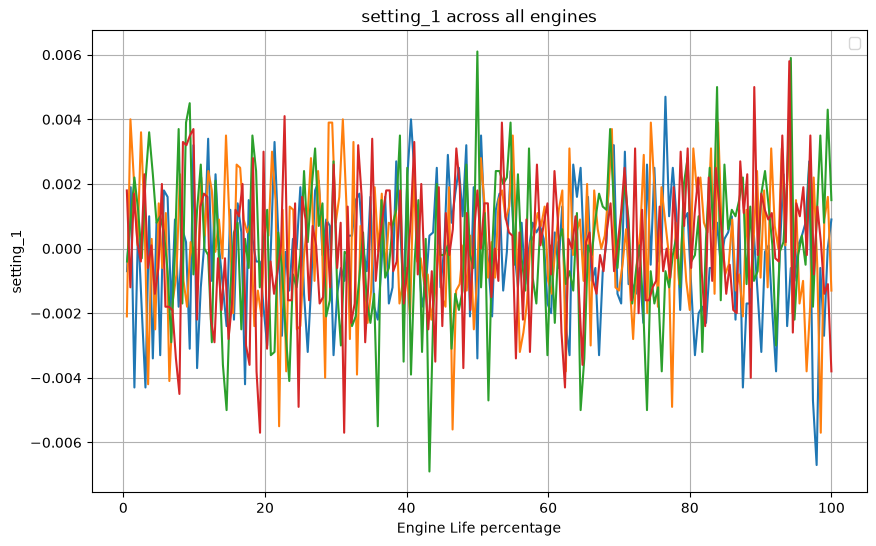

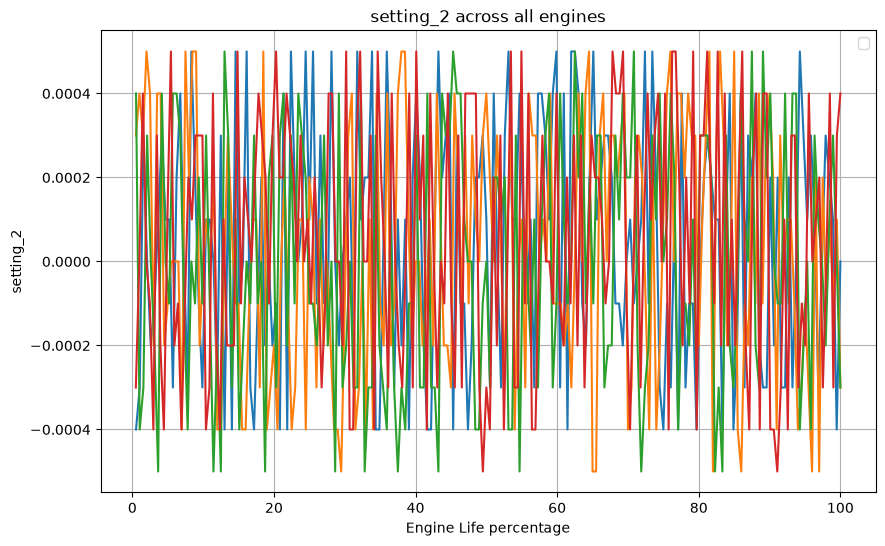

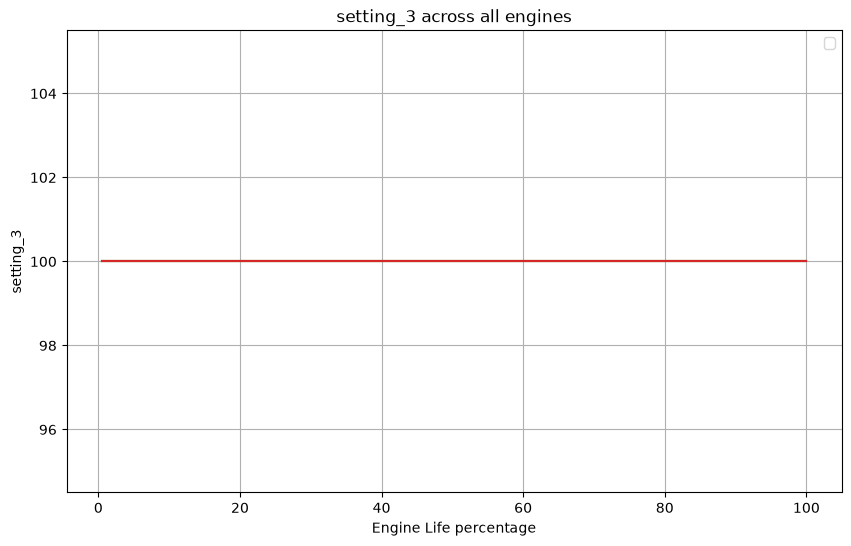

In [14]:
settings=['setting_1','setting_2','setting_3']

for setting in settings:
    plt.figure(figsize=(10,6))
    for engine in [1,33,44,66]:
       
        engine_data=df[df["engine_id"]==engine]
        
        plt.plot(engine_data["life_percent"],engine_data[setting])
    
    
    plt.title( setting +" across all engines")
    plt.xlabel("Engine Life percentage")
    plt.ylabel(setting)
    plt.grid(True)
    plt.legend()
    plt.show()

Setting 1 values vary moderately when measured instaneously but all values seems to bounce around a common average.
Setting 2 values vary highly when measured instaneously but all value seems to bounce around a common average.
Setting 3 values stay constant at 100.

In [15]:
settings=["setting_1","setting_2","setting_3"]

for setting in settings:
    correlation= df['life_percent'].corr(df[setting])
    
    print(f'{setting}:{correlation:.3f}')


setting_1:0.000
setting_2:0.009
setting_3:nan


/Users/tiwafadeni/Desktop/Engineering Data Analysis Portfolio/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tiwafadeni/Desktop/Engineering Data Analysis Portfolio/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [16]:
correlation_table=df[settings+key_sensors].corr()

correlation_table

,setting_1,setting_2,setting_3,sensor_4,sensor_7,sensor_11,sensor_12,sensor_15
setting_1,1.000000,0.011660,NaN,0.009544,-0.009437,0.011658,-0.001491,0.007652
setting_2,0.011660,1.000000,NaN,0.014673,-0.016678,0.011690,-0.010923,0.014156
setting_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensor_4,0.009544,0.014673,NaN,1.000000,-0.793130,0.830136,-0.815591,0.758459
sensor_7,-0.009437,-0.016678,NaN,-0.793130,1.000000,-0.822805,0.812713,-0.747051
sensor_11,0.011658,0.011690,NaN,0.830136,-0.822805,1.000000,-0.846884,0.780913
sensor_12,-0.001491,-0.010923,NaN,-0.815591,0.812713,-0.846884,1.000000,-0.766052
sensor_15,0.007652,0.014156,NaN,0.758459,-0.747051,0.780913,-0.766052,1.000000


In [18]:
setting_sensor_correlation=correlation_table.loc[settings,key_sensors]

setting_sensor_correlation

,sensor_4,sensor_7,sensor_11,sensor_12,sensor_15
setting_1,0.009544,-0.009437,0.011658,-0.001491,0.007652
setting_2,0.014673,-0.016678,0.011690,-0.010923,0.014156
setting_3,NaN,NaN,NaN,NaN,NaN


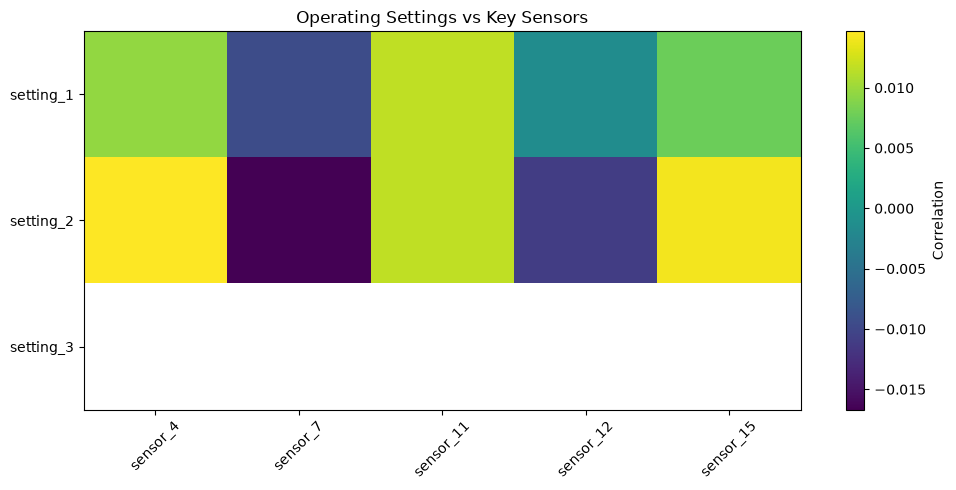

In [23]:
plt.figure(figsize=(10,5))

plt.imshow(setting_sensor_correlation,aspect='auto')

plt.colorbar(label='Correlation')
plt.xticks(range(len(key_sensors)),key_sensors,rotation=45)
plt.yticks(range(len(settings)),settings)
plt.title('Operating Settings vs Key Sensors')
plt.tight_layout()
plt.savefig('../figures/11_Operating Settings vs Key Sensors(HeatMap)')
plt.show()

All correlation values are fairly low,but relatively Sensor 4 and seeting 2 have the highest correlation and sensor7 and setting 2 have the lowest correlation. 

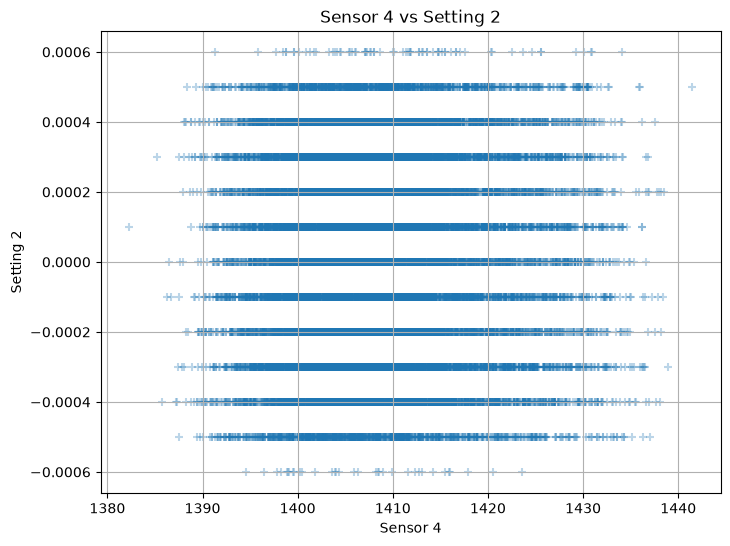

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(df['sensor_4'],df['setting_2'],alpha=0.3,marker='+')

plt.title('Sensor 4 vs Setting 2')
plt.xlabel('Sensor 4')
plt.ylabel('Setting 2')
plt.grid(True)

plt.show()

The scatter plot of Sensor 4 versus Setting 2 shows no clear linear relationship between the two variables. The data points form several horizontal bands corresponding to the different Setting 2 values, while Sensor 4 varies considerably within each operating condition.

## Evaluation

The operating-condition analysis was conducted to determine whether changes in the three engine operating settings could explain the trends observed in the five candidate degradation sensors.

Setting 1 varied between approximately -0.0087 and 0.0087, while Setting 2 varied between approximately -0.0006 and 0.0006. Although both settings exhibited variation, their values generally fluctuated around a common average rather than showing an obvious systematic trend. Setting 3 remained constant at a value of 100 throughout the dataset and therefore had a standard deviation of zero. Because Setting 3 does not vary, its correlation with the sensor measurements is mathematically undefined, resulting in NaN values.

The correlations between Settings 1 and 2 and the five candidate sensors were all very weak, with absolute correlation values below 0.02. The strongest positive relationship was between Setting 2 and Sensor 4 (r = 0.0147), while the strongest negative relationship was between Setting 2 and Sensor 7 (r = -0.0167). Despite being the largest correlations among the operating-setting relationships, these values indicate negligible linear relationships.

These results suggest that the strong relationships previously observed between Sensors 4, 7, 11, 12, and 15 and normalized engine life are not strongly associated with the three measured operating settings. This provides additional support for investigating these sensors as potential indicators of engine aging. However, correlation alone cannot completely eliminate the influence of operating conditions, so further analysis would be required to establish causation.